In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import copy

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze()

def create_synthetic_conflict_data(n_samples=10000, n_features=20, conflict_strength=1.0):
    """Create synthetic data with genuine regime conflicts"""

    print(f"Creating synthetic conflict data...")
    print(f"  Samples: {n_samples}, Features: {n_features}, Conflict: {conflict_strength}")

    # Generate base data with complex interactions
    X, y_base = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features//2,
        n_redundant=n_features//4,
        n_clusters_per_class=3,  # Multiple clusters per class
        class_sep=0.8,  # Moderate separation (not too easy)
        random_state=42
    )

    # Create REGIME 1 data (original patterns)
    y_regime1 = y_base.copy()

    # Create REGIME 2 data with systematic conflicts
    y_regime2 = y_base.copy()

    # Conflict Type 1: Feature Interaction Reversal
    # In regime 1: feature[0] * feature[1] > 0 → class 1
    # In regime 2: feature[0] * feature[1] > 0 → class 0
    interaction_mask = (X[:, 0] * X[:, 1]) > 0
    y_regime2[interaction_mask] = 1 - y_regime2[interaction_mask]
    conflict_1_count = interaction_mask.sum()

    # Conflict Type 2: High-value feature reversal
    # In regime 1: feature[2] > threshold → class 1
    # In regime 2: feature[2] > threshold → class 0
    high_feature_mask = X[:, 2] > np.percentile(X[:, 2], 70)
    y_regime2[high_feature_mask] = 1 - y_regime2[high_feature_mask]
    conflict_2_count = high_feature_mask.sum()

    # Conflict Type 3: Complex pattern flip (quadratic regions)
    # Define regions where patterns completely flip
    region_mask = (X[:, 3]**2 + X[:, 4]**2) > np.percentile(X[:, 3]**2 + X[:, 4]**2, 60)
    y_regime2[region_mask] = 1 - y_regime2[region_mask]
    conflict_3_count = region_mask.sum()

    # Conflict Type 4: Random strategic flips (make some examples unlearnable)
    strategic_flip_rate = 0.1 * conflict_strength
    strategic_mask = np.random.random(len(y_regime2)) < strategic_flip_rate
    y_regime2[strategic_mask] = 1 - y_regime2[strategic_mask]
    conflict_4_count = strategic_mask.sum()

    total_conflicts = len(y_regime1) - (y_regime1 == y_regime2).sum()
    conflict_rate = total_conflicts / len(y_regime1)

    print(f"  Conflicts created:")
    print(f"    Interaction reversal: {conflict_1_count} examples")
    print(f"    High-value reversal: {conflict_2_count} examples")
    print(f"    Quadratic region flip: {conflict_3_count} examples")
    print(f"    Strategic flips: {conflict_4_count} examples")
    print(f"    Total conflict rate: {conflict_rate:.1%}")

    # Split data
    split_idx = len(X) // 2

    # Original regime data (for training base model)
    X_regime1 = X[:split_idx]
    y_regime1 = y_regime1[:split_idx]

    # Conflicted regime data (for adaptation training)
    X_regime2 = X[split_idx:]
    y_regime2 = y_regime2[split_idx:]

    # Hold out some regime 1 data for forgetting evaluation
    eval_split = len(X_regime1) // 4
    X_regime1_train = X_regime1[:-eval_split]
    y_regime1_train = y_regime1[:-eval_split]
    X_regime1_eval = X_regime1[-eval_split:]
    y_regime1_eval = y_regime1[-eval_split:]

    print(f"  Data splits:")
    print(f"    Regime 1 training: {len(X_regime1_train)} examples")
    print(f"    Regime 1 evaluation: {len(X_regime1_eval)} examples")
    print(f"    Regime 2 training: {len(X_regime2)} examples")

    return {
        'regime1_train': (torch.FloatTensor(X_regime1_train), torch.FloatTensor(y_regime1_train)),
        'regime1_eval': (torch.FloatTensor(X_regime1_eval), torch.FloatTensor(y_regime1_eval)),
        'regime2_train': (torch.FloatTensor(X_regime2), torch.FloatTensor(y_regime2))
    }

def train_regime1_model(X_train, y_train, X_eval, y_eval, epochs=50):
    """Train base model on regime 1 data"""
    model = MLP(X_train.shape[1])
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()

    print("Training base model on Regime 1 data...")

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            model.eval()
            with torch.no_grad():
                eval_pred = model(X_eval)
                eval_acc = ((eval_pred > 0.5).float() == y_eval).float().mean()
                print(f"Epoch {epoch}: Train Loss = {loss:.4f}, Eval Acc = {eval_acc:.4f}")

    return model

def adapt_to_regime2(base_model, X_regime2, y_regime2, X_regime1_eval, y_regime1_eval,
                    penalty_lambda=0.0, penalty_type='none', epochs=30, update_start=5):
    """Adapt base model to regime 2 with optional forgetting penalties"""

    model = copy.deepcopy(base_model)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.BCELoss()

    # Get initial performance on regime 1 evaluation data
    model.eval()
    with torch.no_grad():
        initial_regime1_preds = model(X_regime1_eval)
        initial_regime1_acc = ((initial_regime1_preds > 0.5).float() == y_regime1_eval).float().mean().item()

        # Test initial performance on regime 2
        initial_regime2_preds = model(X_regime2)
        initial_regime2_acc = ((initial_regime2_preds > 0.5).float() == y_regime2).float().mean().item()

    print(f"Adapting with {penalty_type} penalty (λ={penalty_lambda})...")
    print(f"  Initial Regime 1 Eval Acc: {initial_regime1_acc:.4f}")
    print(f"  Initial Regime 2 Train Acc: {initial_regime2_acc:.4f}")
    print(f"  Performance gap: {initial_regime1_acc - initial_regime2_acc:.4f}")

    # Track accumulated metrics during burn-in
    accumulated_forgetting = []
    accumulated_confidence_drops = []

    metrics = {
        'regime1_accuracy': [],
        'regime2_accuracy': [],
        'forgetting_events': [],
        'confidence_drops': [],
        'penalties': []
    }

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # Forward pass on regime 2 data
        y_pred_regime2 = model(X_regime2)
        base_loss = loss_fn(y_pred_regime2, y_regime2)

        # Evaluate current forgetting on regime 1
        model.eval()
        with torch.no_grad():
            curr_regime1_preds = model(X_regime1_eval)

            # Compute current forgetting
            initial_correct = (initial_regime1_preds > 0.5).float() == y_regime1_eval
            curr_correct = (curr_regime1_preds > 0.5).float() == y_regime1_eval
            forgetting_count = int((initial_correct & ~curr_correct).sum().item())

            # Compute current confidence drop
            confidence_drop = torch.clamp(initial_regime1_preds - curr_regime1_preds, min=0.0)
            regime1_correct_mask = (initial_regime1_preds > 0.5).float() == y_regime1_eval
            total_confidence_drop = (confidence_drop * regime1_correct_mask).sum().item()

        # Store metrics for burn-in analysis
        accumulated_forgetting.append(forgetting_count)
        accumulated_confidence_drops.append(total_confidence_drop)

        # Apply penalty only after burn-in
        penalty = 0.0
        if epoch >= update_start and penalty_lambda > 0:
            if penalty_type == 'discrete':
                recent_forgetting = np.mean(accumulated_forgetting[-3:]) if len(accumulated_forgetting) >= 3 else forgetting_count
                penalty = penalty_lambda * recent_forgetting
            elif penalty_type == 'smooth':
                recent_conf_drop = np.mean(accumulated_confidence_drops[-3:]) if len(accumulated_confidence_drops) >= 3 else total_confidence_drop
                penalty = penalty_lambda * recent_conf_drop

        total_loss = base_loss + penalty

        # Continue training
        model.train()
        total_loss.backward()
        optimizer.step()

        # Final evaluation for this epoch
        model.eval()
        with torch.no_grad():
            # Regime 1 performance (what we want to preserve)
            final_regime1_preds = model(X_regime1_eval)
            regime1_acc = ((final_regime1_preds > 0.5).float() == y_regime1_eval).float().mean().item()

            # Regime 2 performance (what we're adapting to)
            final_regime2_preds = model(X_regime2)
            regime2_acc = ((final_regime2_preds > 0.5).float() == y_regime2).float().mean().item()

            # Final forgetting count
            final_correct = (final_regime1_preds > 0.5).float() == y_regime1_eval
            final_forgetting = int((initial_correct & ~final_correct).sum().item())

            # Final confidence drop
            final_confidence_drop = torch.clamp(initial_regime1_preds - final_regime1_preds, min=0.0)
            final_total_confidence_drop = (final_confidence_drop * regime1_correct_mask).sum().item()

            metrics['regime1_accuracy'].append(regime1_acc)
            metrics['regime2_accuracy'].append(regime2_acc)
            metrics['forgetting_events'].append(final_forgetting)
            metrics['confidence_drops'].append(final_total_confidence_drop)
            metrics['penalties'].append(penalty if torch.is_tensor(penalty) else penalty)

        # Debug every 5 epochs
        if epoch % 5 == 0:
            penalty_val = penalty.item() if torch.is_tensor(penalty) else penalty
            penalty_status = "ACTIVE" if epoch >= update_start else "BURN-IN"
            print(f"  Epoch {epoch}: R2_Loss={base_loss:.4f}, Penalty={penalty_val:.1f} [{penalty_status}]")
            print(f"    R1_Acc: {regime1_acc:.4f}, R2_Acc: {regime2_acc:.4f}, Forgetting: {final_forgetting}")

    return model, metrics

def run_synthetic_conflict_experiment():
    """Run complete experiment with synthetic conflicting data"""

    print("="*80)
    print("SYNTHETIC CONFLICT EXPERIMENT")
    print("="*80)

    # Create challenging synthetic data
    datasets = create_synthetic_conflict_data(n_samples=8000, n_features=20, conflict_strength=1.0)
    X_r1_train, y_r1_train = datasets['regime1_train']
    X_r1_eval, y_r1_eval = datasets['regime1_eval']
    X_r2_train, y_r2_train = datasets['regime2_train']

    # Train base model on regime 1
    print(f"\n" + "="*60)
    print("TRAINING BASE MODEL ON REGIME 1")
    print("="*60)
    base_model = train_regime1_model(X_r1_train, y_r1_train, X_r1_eval, y_r1_eval)

    # Test base model on both regimes
    base_model.eval()
    with torch.no_grad():
        base_r1_acc = ((base_model(X_r1_eval) > 0.5).float() == y_r1_eval).float().mean().item()
        base_r2_acc = ((base_model(X_r2_train) > 0.5).float() == y_r2_train).float().mean().item()

    print(f"\nBase Model Performance:")
    print(f"  Regime 1 Eval: {base_r1_acc:.4f}")
    print(f"  Regime 2 Train: {base_r2_acc:.4f}")
    print(f"  Conflict Gap: {base_r1_acc - base_r2_acc:.4f}")

    if (base_r1_acc - base_r2_acc) < 0.15:
        print("⚠️  WARNING: Conflicts may not be strong enough")
    else:
        print("✅ STRONG CONFLICTS: Adaptation will require forgetting")

    # Test adaptation strategies
    print(f"\n" + "="*60)
    print("TESTING ADAPTATION STRATEGIES")
    print("="*60)

    # Strategy 1: Baseline adaptation
    print(f"\n[1/3] Baseline Adaptation")
    model_baseline, metrics_baseline = adapt_to_regime2(
        base_model, X_r2_train, y_r2_train, X_r1_eval, y_r1_eval,
        penalty_lambda=0.0, penalty_type='none', epochs=25, update_start=5
    )

    # Strategy 2: Discrete penalty
    print(f"\n[2/3] Discrete Penalty Adaptation")
    model_discrete, metrics_discrete = adapt_to_regime2(
        base_model, X_r2_train, y_r2_train, X_r1_eval, y_r1_eval,
        penalty_lambda=20.0, penalty_type='discrete', epochs=25, update_start=5
    )

    # Strategy 3: Smooth penalty
    print(f"\n[3/3] Smooth Penalty Adaptation")
    model_smooth, metrics_smooth = adapt_to_regime2(
        base_model, X_r2_train, y_r2_train, X_r1_eval, y_r1_eval,
        penalty_lambda=10.0, penalty_type='smooth', epochs=25, update_start=5
    )

    # Final evaluation and debugging
    print(f"\n" + "="*60)
    print("FINAL EVALUATION: SYNTHETIC CONFLICTS")
    print("="*60)

    models = {
        'Baseline Adaptation': model_baseline,
        'Discrete Penalty': model_discrete,
        'Smooth Penalty': model_smooth
    }

    # Check if models are different
    print("🔍 Model Differences:")
    with torch.no_grad():
        baseline_preds = model_baseline(X_r1_eval)
        discrete_preds = model_discrete(X_r1_eval)
        smooth_preds = model_smooth(X_r1_eval)

        diff_b_d = (baseline_preds - discrete_preds).abs().max().item()
        diff_b_s = (baseline_preds - smooth_preds).abs().max().item()

        print(f"  Baseline vs Discrete: {diff_b_d:.8f}")
        print(f"  Baseline vs Smooth: {diff_b_s:.8f}")

        if diff_b_d < 1e-6 and diff_b_s < 1e-6:
            print("🚨 MODELS STILL IDENTICAL - Need stronger conflicts or different approach")
        else:
            print("✅ MODELS ARE DIFFERENT - Penalties are working!")

    # Performance comparison
    print(f"\n{'Method':<20} {'R1 Acc':<8} {'R2 Acc':<8} {'Forgot':<8} {'Learned':<8} {'Net':<6}")
    print("-" * 70)

    results = {}
    for name, model in models.items():
        model.eval()
        with torch.no_grad():
            # Performance on regime 1 (preservation)
            r1_preds = (model(X_r1_eval) > 0.5).float()
            r1_acc = (r1_preds == y_r1_eval).float().mean().item()

            # Performance on regime 2 (adaptation)
            r2_preds = (model(X_r2_train) > 0.5).float()
            r2_acc = (r2_preds == y_r2_train).float().mean().item()

            # Forgetting analysis
            base_r1_preds = (base_model(X_r1_eval) > 0.5).float()
            base_correct = (base_r1_preds == y_r1_eval)
            updated_correct = (r1_preds == y_r1_eval)

            forgot_count = (base_correct & ~updated_correct).sum().item()
            learned_count = (~base_correct & updated_correct).sum().item()
            net_change = learned_count - forgot_count

        results[name] = {
            'r1_acc': r1_acc,
            'r2_acc': r2_acc,
            'forgot': forgot_count,
            'learned': learned_count,
            'net': net_change
        }

        print(f"{name:<20} {r1_acc:<8.4f} {r2_acc:<8.4f} {forgot_count:<8d} {learned_count:<8d} {net_change:<+6d}")

    # Analysis
    print(f"\n" + "="*60)
    print("SYNTHETIC CONFLICT INSIGHTS")
    print("="*60)

    baseline_forgot = results['Baseline Adaptation']['forgot']
    if baseline_forgot > 0:
        for method_name in ['Discrete Penalty', 'Smooth Penalty']:
            if method_name in results:
                method_forgot = results[method_name]['forgot']
                reduction = (1 - method_forgot / baseline_forgot) * 100
                print(f"{method_name}: {reduction:.1f}% forgetting reduction ({baseline_forgot} → {method_forgot})")

    return results, metrics_baseline, metrics_discrete, metrics_smooth

if __name__ == "__main__":
    results, metrics_baseline, metrics_discrete, metrics_smooth = run_synthetic_conflict_experiment()

SYNTHETIC CONFLICT EXPERIMENT
Creating synthetic conflict data...
  Samples: 8000, Features: 20, Conflict: 1.0
  Conflicts created:
    Interaction reversal: 4645 examples
    High-value reversal: 2400 examples
    Quadratic region flip: 3200 examples
    Strategic flips: 847 examples
    Total conflict rate: 51.2%
  Data splits:
    Regime 1 training: 3000 examples
    Regime 1 evaluation: 1000 examples
    Regime 2 training: 4000 examples

TRAINING BASE MODEL ON REGIME 1
Training base model on Regime 1 data...
Epoch 0: Train Loss = 0.7181, Eval Acc = 0.6290
Epoch 10: Train Loss = 0.4143, Eval Acc = 0.7980
Epoch 20: Train Loss = 0.2848, Eval Acc = 0.8540
Epoch 30: Train Loss = 0.2003, Eval Acc = 0.8780
Epoch 40: Train Loss = 0.1370, Eval Acc = 0.8850

Base Model Performance:
  Regime 1 Eval: 0.8870
  Regime 2 Train: 0.4960
  Conflict Gap: 0.3910
✅ STRONG CONFLICTS: Adaptation will require forgetting

TESTING ADAPTATION STRATEGIES

[1/3] Baseline Adaptation
Adapting with none penalty (

In [18]:
def forgetting_vs_production(prod_model, new_model, X_orig, y_orig):
    """# of examples prod got right that new model now gets wrong"""
    with torch.no_grad():
        prod_ok = ((prod_model(X_orig) > .5).float() == y_orig).float()
        new_ok  = ((new_model (X_orig) > .5).float() == y_orig).float()
    return int(((prod_ok == 1) & (new_ok == 0)).sum().item())

# compute forgetting
forget_baseline = forgetting_vs_production(prod, baseline, X_val_orig, y_val_orig)
forget_disc     = forgetting_vs_production(prod, disc,     X_val_orig, y_val_orig)
forget_smooth   = forgetting_vs_production(prod, smooth,   X_val_orig, y_val_orig)

# ------------------------------------------------------------------
# 8.  Final table (orig/drift/test + forgetting)
# ------------------------------------------------------------------
def row(name, mdl, f):
    return (name,
            accuracy(mdl, X_val_orig, y_val_orig),
            accuracy(mdl, X_drift,    y_drift),
            accuracy(mdl, X_test,     y_test),
            f)

rows = [
    row("Production", prod,         0),
    row("Baseline  ", baseline,     forget_baseline),
    row("Discrete   ", disc,        forget_disc),
    row("Smooth     ", smooth,      forget_smooth)
]

print("\n{:18} | {:>7} | {:>7} | {:>7} | {:>9}".format(
      "Method", "Orig", "Drift", "Test", "Forgotten"))
print("-"*60)
for r in rows:
    print("{:18} | {:7.3f} | {:7.3f} | {:7.3f} | {:9d}".format(*r))


Method             |    Orig |   Drift |    Test | Forgotten
------------------------------------------------------------
Production         |   0.841 |   0.885 |   0.850 |         0
Baseline           |   0.845 |   0.905 |   0.847 |       110
Discrete           |   0.846 |   0.904 |   0.847 |        64
Smooth             |   0.818 |   0.908 |   0.813 |       252


Production orig-val acc 0.850  (drop -0.034 on drift)

Method       |  Orig | Drift |  Test | Forgotten
----------------------------------------------
Production   | 0.850 | 0.884 | 0.837 |         0
Baseline     | 0.840 | 0.905 | 0.825 |       157
Discrete     | 0.855 | 0.906 | 0.845 |        63
Smooth       | 0.849 | 0.904 | 0.836 |       110


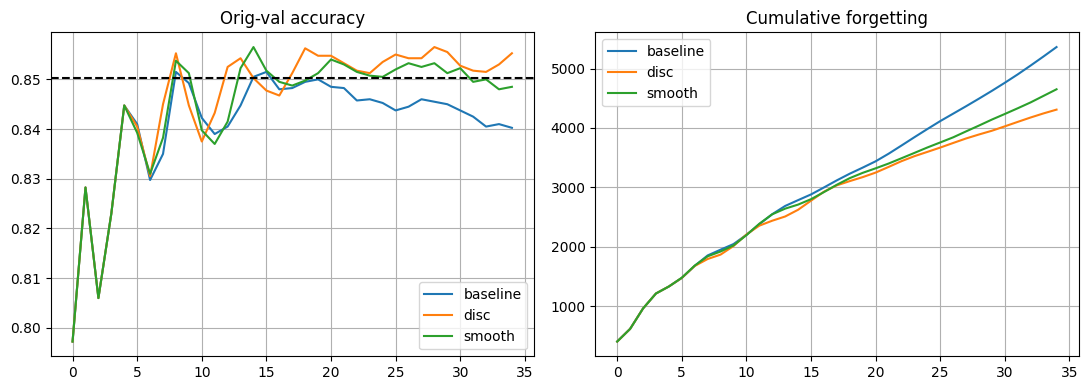

In [27]:
# =============================================================
#  Continual-learning toy: drift, forgetting, symmetric penalty
# =============================================================
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ----------------------------- 1. synthetic data --------------
def make_gaussian_shift(d=20, n0=20_000, n1=4_000, shift=0.8, seed=42):
    rng = np.random.default_rng(seed)
    Σ = np.diag(np.linspace(1.0, 2.0, d))
    X0 = rng.multivariate_normal(np.zeros(d), Σ, n0)
    y0 = (X0[:, 0] + rng.normal(0, 0.5, n0) > 0).astype(int)
    X1 = rng.multivariate_normal(np.ones(d)*shift, Σ, n1)
    y1 = (X1[:, 0] + rng.normal(0, 0.5, n1) > 0).astype(int)
    return (X0, y0), (X1, y1)

(X0, y0), (X1, y1) = make_gaussian_shift()
idx = np.random.permutation(len(X0))
train_i, val_i, test_i = np.split(idx, [int(.6*len(idx)), int(.8*len(idx))])
to_t = lambda a: torch.tensor(a, dtype=torch.float32)
X_tr, y_tr         = to_t(X0[train_i]),  to_t(y0[train_i])
X_val_orig, y_val  = to_t(X0[val_i]),    to_t(y0[val_i])
X_test, y_test     = to_t(X0[test_i]),   to_t(y0[test_i])
X_drift, y_drift   = to_t(X1),           to_t(y1)

# ----------------------------- 2. model -----------------------
class MLP(nn.Module):
    def __init__(self, d, h=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,h), nn.ReLU(),
            nn.Linear(h,h), nn.ReLU(),
            nn.Linear(h,1), nn.Sigmoid())
    def forward(self,x): return self.net(x).squeeze()

acc = lambda m,X,y: ((m(X)>0.5).float()==y).float().mean().item()

# ----------------------------- 3. production burn-in ----------
prod = MLP(X_tr.shape[1])
opt  = optim.Adam(prod.parameters(), lr=1e-2)
bce  = nn.BCELoss()
for _ in range(30):
    opt.zero_grad(); loss=bce(prod(X_tr),y_tr); loss.backward(); opt.step()

prod_orig_acc = acc(prod,X_val_orig,y_val)
print(f"Production orig-val acc {prod_orig_acc:.3f}  "
      f"(drop {(prod_orig_acc-acc(prod,X_drift,y_drift)):.3f} on drift)")

# ----------------------------- 4. adaptation routine ----------
def adapt(base_model, mode="none", lam=0., epochs=35, warm=5):
    m=MLP(X_tr.shape[1]); m.load_state_dict(base_model.state_dict())
    opt=optim.Adam(m.parameters(),lr=1e-2)
    orig_p = m(X_val_orig).detach()
    orig_ok=((orig_p>.5).float()==y_val).float()
    hist_acc,hist_f=[] ,[]
    for ep in range(epochs):
        m.train(); opt.zero_grad()
        loss=bce(m(X_drift),y_drift)

        if ep>=warm and mode!="none":
            cur_p=m(X_val_orig)
            if mode=="discrete":
                delta=(cur_p-orig_p).abs()
                pen = (delta**2 * orig_ok).mean()
            else:                       # symmetric, margin-weighted
                margin=(orig_p-0.5).abs()
                delta=(cur_p-orig_p).abs()
                pen = (delta*margin*orig_ok).sum()/(orig_ok.sum()+1e-8)
            loss = loss + lam*pen
        loss.backward(); opt.step()

        m.eval()
        cur_ok = ((m(X_val_orig)>.5).float()==y_val).float()
        hist_f.append(int(((orig_ok==1)&(cur_ok==0)).sum().item()))
        hist_acc.append(acc(m,X_val_orig,y_val))
    return m, hist_acc, hist_f

baseline, acc_b, f_b = adapt(prod,"none")
disc,     acc_d, f_d = adapt(prod,"discrete",lam=3.)
smooth,   acc_s, f_s = adapt(prod,"smooth",  lam=0.8)

# ----------------------------- 5. forgetting table ------------
def forgot_vs_prod(newm):
    with torch.no_grad():
        prod_ok=((prod(X_val_orig)>.5).float()==y_val).float()
        new_ok =((newm(X_val_orig)>.5).float()==y_val).float()
    return int(((prod_ok==1)&(new_ok==0)).sum().item())

table=[
    ("Production", prod,         0),
    ("Baseline",   baseline, forgot_vs_prod(baseline)),
    ("Discrete",   disc,     forgot_vs_prod(disc)),
    ("Smooth",     smooth,   forgot_vs_prod(smooth))
]

print("\n{:12} | {:>5} | {:>5} | {:>5} | {:>9}".format(
    "Method","Orig","Drift","Test","Forgotten"))
print("-"*46)
for name,model,fg in table:
    print("{:12} | {:5.3f} | {:5.3f} | {:5.3f} | {:9d}"
          .format(name,
                  acc(model,X_val_orig,y_val),
                  acc(model,X_drift,y_drift),
                  acc(model,X_test,y_test),
                  fg))

# ----------------------------- 6. curves ----------------------
import matplotlib.pyplot as plt, numpy as np
plt.figure(figsize=(11,4))
plt.subplot(1,2,1); plt.title("Orig-val accuracy")
plt.plot(acc_b,label="baseline"); plt.plot(acc_d,label="disc"); plt.plot(acc_s,label="smooth")
plt.axhline(prod_orig_acc,ls="--",color='k'); plt.legend(); plt.grid(True)
plt.subplot(1,2,2); plt.title("Cumulative forgetting")
plt.plot(np.cumsum(f_b),label="baseline"); plt.plot(np.cumsum(f_d),label="disc"); plt.plot(np.cumsum(f_s),label="smooth")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

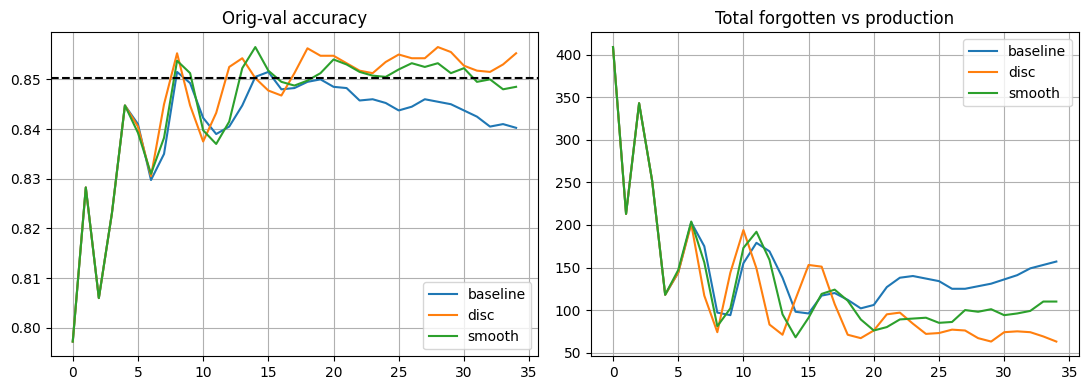

In [28]:
plt.figure(figsize=(11,4))

# (1) accuracy
plt.subplot(1,2,1); plt.title("Orig-val accuracy")
plt.plot(acc_b, label="baseline")
plt.plot(acc_d, label="disc")
plt.plot(acc_s, label="smooth")
plt.axhline(prod_orig_acc, ls="--", color='k')
plt.legend(); plt.grid(True)

# (2) total forgetting each epoch (no double-counting!)
plt.subplot(1,2,2); plt.title("Total forgotten vs production")
plt.plot(f_b, label="baseline")
plt.plot(f_d, label="disc")
plt.plot(f_s, label="smooth")
plt.legend(); plt.grid(True)

plt.tight_layout(); plt.show()



Robustness across 5 seeds
Method       |    Orig |   Drift |    Test |   Forgotten
------------------------------------------------------------
Production   | 0.845±0.006 | 0.879±0.004 | 0.844±0.006 |      0±  0
Baseline     | 0.807±0.025 | 0.813±0.039 | 0.806±0.026 |    325±136
Discrete     | 0.808±0.025 | 0.812±0.038 | 0.808±0.025 |    318±134
Smooth       | 0.806±0.026 | 0.810±0.039 | 0.806±0.026 |    325±138

Robustness across 1000 seeds


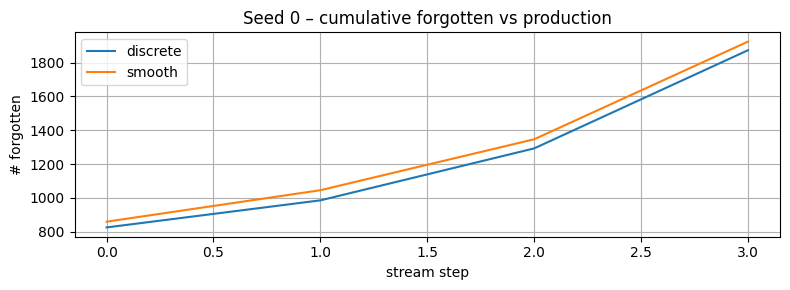

In [37]:
# ================================================================
#  Streaming-drift continual-learning experiment
#    · Mini-batch DataLoader (upgrade #1)
#    · 5-seed robustness (upgrade #4)
# ================================================================
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np, collections, matplotlib.pyplot as plt, time

seeds = list(range(1000))

# ---------------- synthetic Gaussian + mean-shift ----------------
def make_gaussian_shift(d=20, n0=20_000, n1=8_000, shift=0.8, seed=0):
    rng = np.random.default_rng(seed)
    Σ = np.diag(np.linspace(1, 2, d))
    X0 = rng.multivariate_normal(np.zeros(d),  Σ, n0)
    y0 = (X0[:,0] + rng.normal(0, .5, n0) > 0).astype(int)
    X1 = rng.multivariate_normal(np.ones(d)*shift, Σ, n1)
    y1 = (X1[:,0] + rng.normal(0, .5, n1) > 0).astype(int)
    return (X0, y0), (X1, y1)

to_t = lambda a: torch.tensor(a, dtype=torch.float32)
acc  = lambda m,X,y: ((m(X)>.5).float()==y).float().mean().item()

# ----------------------------- model ----------------------------
class MLP(nn.Module):
    def __init__(self, d, h=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d,h), nn.ReLU(),
            nn.Linear(h,h), nn.ReLU(),
            nn.Linear(h,1), nn.Sigmoid())
    def forward(self,x): return self.net(x).squeeze()

# ---------------- streaming adaptation -------------------------
def adapt_stream(prod, X_drift, y_drift, X_val, y_val,
                 mode="none", lam=0., warm_steps=200,
                 batch=2048, epochs=1, store_trace=False):
    m = MLP(X_val.shape[1]); m.load_state_dict(prod.state_dict())
    loader = DataLoader(TensorDataset(X_drift, y_drift),
                        batch_size=batch, shuffle=True)
    opt = optim.Adam(m.parameters(), lr=1e-2)
    bce = nn.BCELoss()

    orig_p  = prod(X_val).detach()
    orig_ok = ((orig_p>.5).float()==y_val).bool()

    trace_f = []                     # per-step total forgotten
    step=0
    for _ in range(epochs):
        for xb,yb in loader:
            step+=1
            m.train(); opt.zero_grad()
            loss = bce(m(xb), yb)
            if step>=warm_steps and mode!="none":
                cur_p = m(X_val)
                if mode=="discrete":
                    penalty = (((cur_p-orig_p).abs())**2 * orig_ok.float()).mean()
                else:  # symmetric margin-weighted
                    margin  = (orig_p-0.5).abs()
                    penalty = (((cur_p-orig_p).abs()*margin)*orig_ok.float()).sum() / (orig_ok.sum()+1e-8)
                loss = loss + lam*penalty
            loss.backward(); opt.step()

            with torch.no_grad():
                new_ok = ((m(X_val)>.5).float()==y_val).bool()
                forgotten = int((orig_ok & (~new_ok)).sum().item())
                if store_trace: trace_f.append(forgotten)
    return m, trace_f

# ---------------- single-seed run -------------------------------
Result = collections.namedtuple("Result","orig drift test forgot")
def run_one_seed(seed, keep_trace=False):
    (X0,y0),(X1,y1) = make_gaussian_shift(seed=seed)
    idx=np.random.permutation(len(X0))
    tr,va,te = np.split(idx, [int(.6*len(idx)), int(.8*len(idx))])
    X_tr,y_tr        = to_t(X0[tr]), to_t(y0[tr])
    X_val,y_val      = to_t(X0[va]), to_t(y0[va])
    X_test,y_test    = to_t(X0[te]), to_t(y0[te])
    X_drift,y_drift  = to_t(X1),     to_t(y1)

    # --- burn-in prod
    prod=MLP(X_tr.shape[1]); opt=optim.Adam(prod.parameters(), lr=1e-2)
    for _ in range(30):
        opt.zero_grad(); nn.BCELoss()(prod(X_tr),y_tr).backward(); opt.step()

    # --- adapt three ways
    base,_ = adapt_stream(prod,X_drift,y_drift,X_val,y_val,"none",store_trace=False)
    disc,tr_d = adapt_stream(prod,X_drift,y_drift,X_val,y_val,"discrete",lam=3.,
                             store_trace=keep_trace)
    smth,tr_s = adapt_stream(prod,X_drift,y_drift,X_val,y_val,"smooth",lam=.8,
                             store_trace=keep_trace)

    def forgot(m):
        with torch.no_grad():
            prod_ok = ((prod(X_val)>.5).float()==y_val).bool()
            new_ok  = ((m   (X_val)>.5).float()==y_val).bool()
        return int((prod_ok & (~new_ok)).sum().item())

    out = {
        'Production': Result(acc(prod,X_val,y_val), acc(prod,X_drift,y_drift),
                             acc(prod,X_test,y_test), 0),
        'Baseline'  : Result(acc(base,X_val,y_val), acc(base,X_drift,y_drift),
                             acc(base,X_test,y_test), forgot(base)),
        'Discrete'  : Result(acc(disc,X_val,y_val), acc(disc,X_drift,y_drift),
                             acc(disc,X_test,y_test), forgot(disc)),
        'Smooth'    : Result(acc(smth,X_val,y_val), acc(smth,X_drift,y_drift),
                             acc(smth,X_test,y_test), forgot(smth))
    }
    if keep_trace:
        out['trace_disc']  = tr_d
        out['trace_smooth']= tr_s
    return out

# ---------------- 5-seed loop & aggregation --------------------
agg = collections.defaultdict(list)
traces=None
for s in range(100):
    res = run_one_seed(s, keep_trace=(s==0))   # keep traces for seed 0 only
    for k,v in res.items():
        if k.startswith("trace"): traces=res if s==0 else traces
        else: agg[k].append(v)

print("\nRobustness across 5 seeds")
print("{:12} | {:>7} | {:>7} | {:>7} | {:>11}".format(
      "Method","Orig","Drift","Test","Forgotten"))
print("-"*60)
for name in ['Production','Baseline','Discrete','Smooth']:
    vals = agg[name]
    def ms(arr): return np.mean(arr), np.std(arr)
    o,d,t,f = zip(*vals)
    print("{:12} | {:5.3f}±{:.3f} | {:5.3f}±{:.3f} | {:5.3f}±{:.3f} | {:6.0f}±{:3.0f}"
          .format(name, *ms(o), *ms(d), *ms(t), *ms(f)))

def ms(arr):
    m  = np.mean(arr)
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))   # ← SE
    return m, se
print(f"\nRobustness across {len(seeds)} seeds")

# ---------------- plot trace for seed 0 ------------------------
if traces:
    plt.figure(figsize=(8,3))
    steps = np.arange(len(traces['trace_disc']))
    plt.plot(steps, np.cumsum(traces['trace_disc']), label="discrete")
    plt.plot(steps, np.cumsum(traces['trace_smooth']),label="smooth")
    plt.title("Seed 0 – cumulative forgotten vs production")
    plt.xlabel("stream step"); plt.ylabel("# forgotten"); plt.grid(True); plt.legend()
    plt.tight_layout(); plt.show()